In [2]:
# # Clone repository
# !git clone https://github.com/zeinabyazdani/Trustworthy-AI-Mini-Projects.git

In [3]:
# # Update changes in repo
# # %cd /kaggle/working/Trustworthy-AI-Mini-Projects
# # !git pull origin main
# %cd '/kaggle/working/Trustworthy-AI-Mini-Projects/Robustness'

In [4]:
# import sys
# sys.path.append("/kaggle/working/Trustworthy-AI-Mini-Projects/Robustness")

In [5]:
# !pip install --no-deps -r requirements.txt

In [6]:
!pip install cleverhans
# matplotlib
# numpy
# pyaml
!pip install pytorch-metric-learning
# scikit-learn
# torch
# torchvision
# torchaudio
!pip install umap-learn
!pip install umap-learn pynndescent

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.3/92.3 kB 2.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.9/125.9 kB 3.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 1.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 3.0 MB/s eta 0:00:00


## onfig

In [7]:

# Configuration settings
learning_rate = 0.001
epochs    = 10
batch_size= 512 
val_split = 0.2
model_name= 'model'
epsilon   = 0.1
num_classes= 10
embedding_size= 128
adversary_training= False
use_circle_loss = False



## data loader

In [8]:
import torch
import torchvision
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torch.utils.data as data
from cleverhans.torch.attacks.fast_gradient_method import fast_gradient_method
import numpy as np
import math


def load_data(batch_size=64, val_split=0.2, data_path='.', shuffle_=True):
    """Loads the CIFAR-10 dataset and prepares DataLoaders for training, validation, and testing.

    This function applies transformations, splits the training dataset into training and validation sets,
    and returns DataLoaders for efficient batch processing.

    Args:
        batch_size (int, optional): Number of samples per batch. Defaults to 64.
        val_split (float, optional): Proportion of training data to use for validation (0 to 1). Defaults to 0.2.
        data_path (str, optional): Directory path to download or load the CIFAR-10 dataset. Defaults to '.'.

    Returns:
        tuple: A tuple containing:
            - train_loader (DataLoader): DataLoader for the training set.
            - val_loader (DataLoader): DataLoader for the validation set.
            - test_loader (DataLoader): DataLoader for the test set.
    """

    # Define transforms
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2470, 0.2435, 0.2616]),
    ])

    # Load CIFAR-10 dataset
    train_ds = torchvision.datasets.CIFAR10(root=data_path, train=True, transform=transform, download=True)
    test_ds  = torchvision.datasets.CIFAR10(root=data_path, train=False, transform=transform,download=True)

    # Split train and validation datasets
    indices = np.arange(len(train_ds))
    np.random.shuffle(indices)
    val_size = math.floor(len(train_ds) * val_split)
    train_idx, val_idx = indices[val_size:], indices[:val_size]

    val_ds = torch.utils.data.Subset(train_ds, val_idx)
    train_ds = torch.utils.data.Subset(train_ds, train_idx)
    
    # Create data loader
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=shuffle_)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=shuffle_)
    test_loader  = DataLoader(test_ds, batch_size, shuffle=shuffle_)

    return train_loader, val_loader, test_loader


def generate_adversary_samples(model, images, labels, loss_fn, epsilon=0.1, manual=False, num_pixels=10):
    """
    1. Generates adversarial examples using the Fast Gradient Sign Method (FGSM).
        FGSM attack perturbs the input images to maximize the model's loss, thereby generating adversarial examples.
        The attack can be performed using a manual implementation or CleverHans' `fast_gradient_method`.
    2. Add random noise by change some pixels of the image to a fixed value.


    Args:
        model (torch.nn.Module): The target model to attack.
        images (torch.Tensor): Input images.
        labels (torch.Tensor): True labels corresponding to the input images.
        loss_fn (callable): Loss function used for computing gradients.
        epsilon (float, optional): Magnitude of the perturbation. Defaults to 0.1.
        manual (bool, optional): Whether to use a manual FGSM implementation. Defaults to False.
        num_pixels (int, optional): The number of pixels that change. Defaults to 10.

    Returns:
        torch.Tensor: Adversarial examples generated by FGSM attack and random noise.
    """

    ### FGSM attack ###
    # clone().detach(): create a new copy without dependency on the computation graph.
    images = images.clone().detach().requires_grad_(True)
    batch_size, _, height, width = images.shape
    
    if manual:
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        model.zero_grad()
        loss.backward()
        perturbation = torch.sign(images.grad) * epsilon
        adversary_images = images + perturbation
        # adversary_images = torch.clamp(adversary_images, -1, 1)
        adversary_images = torch.clamp(adversary_images, 0, 1)
    else:
        adversary_images = fast_gradient_method(model, images, epsilon, np.inf)


    ### Add random noise ###
    # adversary_images = adversary_images.clone().detach()
    for i in range(batch_size):
        for _ in range(num_pixels):
            h, w = np.random.randint(0, height), np.random.randint(0, width)
            adversary_images[i, :, h, w] = 1.0  # Whitening the pixel.

    return adversary_images # .detach()



## eval


In [9]:

import torch
import numpy as np
import umap
# import umap.umap_ as umap
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier


# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Global variable to store extracted features
features_list = []


# Hook function to extract output from the avgpool layer
def hook_fn(module, input, output):
    global features_list
    features_list.append(output.flatten(1).cpu().numpy())


# Register a forward hook on the avgpool layer
def register_hook(model):
    layer = model.avgpool  # Get the avgpool layer
    handle = layer.register_forward_hook(hook_fn)
    return handle  # Return handle for later removal


# Extract features from the model
def extract_features(model, dataloader):
    global features_list
    features_list = []  # Clear previous feature list
    hook_handle = register_hook(model)  # Register the hook
    
    model.eval()
    with torch.no_grad():
        for images, _ in dataloader:
            images = images.to(device)
            _ = model(images)  # Forward pass, hook captures avgpool output
    
    hook_handle.remove()  # Remove the hook after extraction
    return np.vstack(features_list)  # Convert list to NumPy array


# Evaluate model using KNN
def knn_accuracy(model, test_loader):

    features = extract_features(model, test_loader)
    # labels = np.array([label for _, label in test_loader.dataset])  # Get labels
    labels = torch.cat([labels for _, labels in test_loader], dim=0).cpu().numpy()
    # labels = torch.tensor(test_loader.dataset.targets).cpu().numpy()

    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(features, labels)
    accuracy = knn.score(features, labels)
    
    return accuracy


# Visualize feature distribution using UMAP
def plot_umap(model, test_loader):
    features = extract_features(model, test_loader)
    # labels = np.array([label for _, label in test_loader.dataset])
    labels = torch.cat([labels for _, labels in test_loader], dim=0).cpu().numpy()
    # labels = torch.tensor(test_loader.dataset.targets).cpu().numpy()
    
    umap_proj = umap.UMAP(n_components=2).fit_transform(features)
    plt.scatter(umap_proj[:, 0], umap_proj[:, 1], c=labels, cmap='Spectral', alpha=0.5)
    plt.title("UMAP Projection of Test Data")
    plt.show()



## train

In [10]:
import torch
import sys
import os
import matplotlib.pyplot as plt
import numpy as np


def training(model, device, train_loader, val_loader,
             loss_fn, optimizer, scheduler=None, epochs=10, adv_function=None,
             model_path=".", model_name='model', plot_loss=True):
    
    # List of training losses for each epoch
    loss_train_epoch = []
    # List of validation losses for each epoch
    loss_val_epoch = []

    model.to(device)

    for epoch in range(epochs):
        
        # Training loss for each batch
        loss_train_batch = 0
        # Index of the batch being processed
        batch_idx = 0

        # Model in training mode
        model.train()

        for images, labels in train_loader:
            # Move data and labels to device
            images, labels = images.to(device), labels.to(device)

            # Generate adversary samples
            if np.random.rand() > 0.5 and adv_function is not None:
                images = adv_function(model, images, labels, loss_fn, epsilon=0.1, manual=False, num_pixels=10)

            # Set gradients of optimizer to zero for each batch
            optimizer.zero_grad()

            # Forward pass (Make predictions for this batch)
            outputs = model(images)

            # Compute the loss and its gradients
            loss = loss_fn(outputs, labels)
            loss.backward()

            # Update weights
            optimizer.step()

            # Gather data and report
            loss_train_batch += loss.item()
            batch_idx += 1
            loss_on_batch = loss_train_batch / batch_idx
            sys.stdout.write('\r' + f"epoch = {epoch + 1}/{epochs}, batch = {batch_idx}, loss_train = {loss_on_batch:0.4f}")

        # Add training loss of each epoch to List
        loss_train_epoch.append(loss_on_batch)

        # scheduler for learning rate
        if scheduler:
            scheduler.step()

        # Model in evaluation mode
        model.eval()
        for images, labels in val_loader:
            # Validation loss for each batch
            loss_val_batch = 0
            # Index of the batch being processed
            val_batch_idx = 0

            images, labels = images.to(device), labels.to(device)

            # Generate adversary samples
            if np.random.rand() > 0.5 and adv_function is not None:
                images = adv_function(model, images, labels, loss_fn, epsilon=0.1, manual=False, num_pixels=10)

            outputs = model(images)
            loss = loss_fn(outputs, labels)

            loss_val_batch += loss.item()
            val_batch_idx += 1
            val_loss_on_batch = loss_val_batch / val_batch_idx

        # Add validation loss of each epoch to List
        loss_val_epoch.append(val_loss_on_batch)

        print('\r' + f"epoch = {epoch + 1}, Train loss = {loss_train_epoch[-1]:0.4f}, Val loss = {loss_val_epoch[-1]:0.4f}")

    # Save model
    PATH = os.path.join('/kaggle/working/', f"{model_name}.pth")
    torch.save(model, PATH)

    if plot_loss:
        # Plot training and validation loss
        plt.figure()
        plt.plot(np.arange(epochs), loss_train_epoch, '-*', color='blue', label='Train')
        plt.plot(np.arange(epochs), loss_val_epoch, '-o', color='orange', label='Validation')
        plt.xlabel('epoch')
        plt.ylabel('loss')
        plt.legend()
        plt.title(f'Final Validation Loss Value = {loss_val_epoch[-1]:.4f}')



## main

In [13]:
import torch
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
from pytorch_metric_learning import losses
from torch.utils.data import DataLoader, TensorDataset
import os
import sys
import yaml


# Find Project directory
try:
    # If running in a `.py` script
    current_dir = os.path.dirname(os.path.abspath(__file__))
    base_dir    = os.path.abspath(os.path.join(current_dir, os.pardir))
except NameError:
    # If running in a `.ipynb` file
    base_dir    = os.getcwd()
print("Base Directory:", base_dir)

# Pathes to save data and trained model
model_path    = os.path.join(base_dir, 'saved_models')
path_save_data= os.path.join(base_dir, 'data', 'dataset')
# # Seting for check robustness
# epsilon = config["epsilon"]
adv_tr  = adversary_training
# use_circle_loss = config["use_circle_loss"]

# Check and set device
print("cuda available?", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load data
train_loader, val_loader, test_loader = load_data(batch_size, val_split, path_save_data, shuffle_=True)


### Define model and loss function ###
# Load pretrained ResNet18 model
model = models.resnet18(pretrained=True)
if use_circle_loss:
    # Replace the final fc layer with a new one for embeddings
    model.fc = nn.Linear(512, embedding_size)
    # Define Circle Loss
    loss_fn = losses.CircleLoss()
else:
    # Replace the final fc layer with a new one for classification
    model.fc = nn.Linear(512, num_classes)
    # Define CrossEntropyLoss
    loss_fn = nn.CrossEntropyLoss()


### Training ###
# Define optimiizer
# optimizer = optim.SGD(model.parameters(), lr=learning_rate)
# optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay=5e-4)
# optimizer = optim.Adam(model.parameters(), lr=learning_rate)
# scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

# optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=5e-4)
# scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)


optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.8, weight_decay=5e-4)
# optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.7)
# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
# scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
scheduler = None

# optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.8, weight_decay=5e-3)
# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

# optimizer = optim.SGD(model.parameters(), lr=0.005, momentum=0.7, weight_decay=1e-2)
# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

# optimizer = optim.SGD(model.parameters(), lr=0.005, weight_decay=1e-4)
# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

Base Directory: /kaggle/working
cuda available? True
Files already downloaded and verified
Files already downloaded and verified


epoch = 1, Train loss = 1.9020, Val loss = 1.5479
epoch = 2, Train loss = 1.3252, Val loss = 1.3135
epoch = 3, Train loss = 1.1020, Val loss = 1.0916
epoch = 4, Train loss = 0.9749, Val loss = 1.0791
epoch = 5, Train loss = 0.8773, Val loss = 0.9750
epoch = 6, Train loss = 0.8033, Val loss = 0.9535
epoch = 7, Train loss = 0.7393, Val loss = 0.8460
epoch = 8, Train loss = 0.6811, Val loss = 1.0018
epoch = 9, Train loss = 0.6339, Val loss = 0.7204
epoch = 10, Train loss = 0.5890, Val loss = 0.9439
epoch = 11, Train loss = 0.5473, Val loss = 0.7948
epoch = 12, Train loss = 0.5073, Val loss = 0.8979
epoch = 13, Train loss = 0.4702, Val loss = 0.9506
epoch = 14, Train loss = 0.4368, Val loss = 0.9725
epoch = 15, Train loss = 0.3988, Val loss = 0.8865
epoch = 16, Train loss = 0.3620, Val loss = 0.9734
epoch = 17, Train loss = 0.3378, Val loss = 0.8231
epoch = 18, Train loss = 0.3059, Val loss = 0.8470
epoch = 19, Train loss = 0.2781, Val loss = 0.8969
epoch = 20, Train loss = 0.2516, Val los

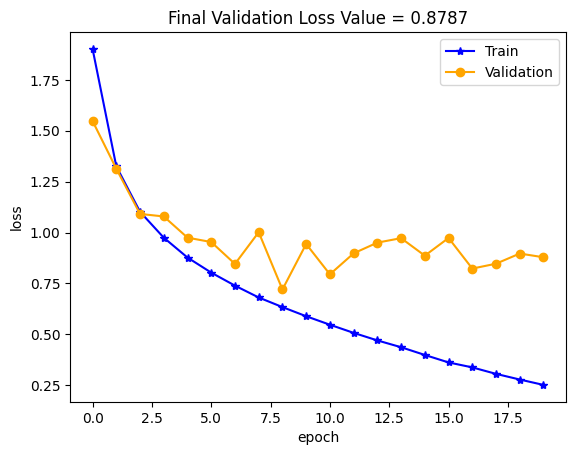

In [14]:
epochs = 20
# Training
training(model, device, train_loader, val_loader, 
         loss_fn, optimizer, scheduler, epochs, 
         generate_adversary_samples if adv_tr else None, 
         model_path, model_name=model_name, plot_loss=True)

Files already downloaded and verified
Files already downloaded and verified
Model Performance on train set
0.866275


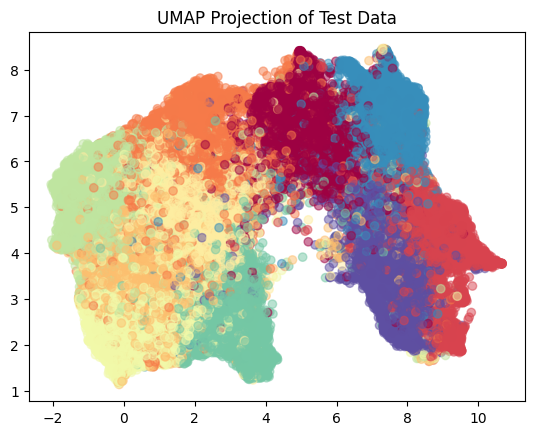

Model Performance on val set
0.8517


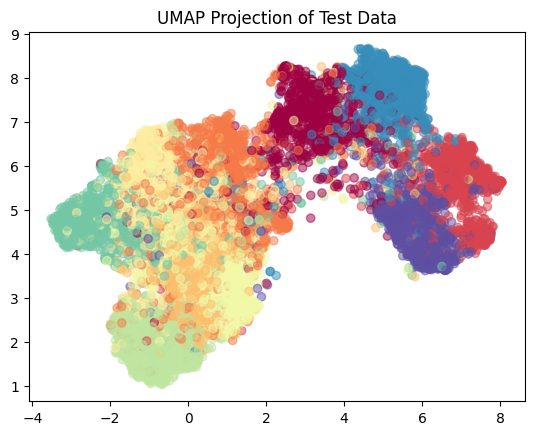

Model Performance on test set
0.7552


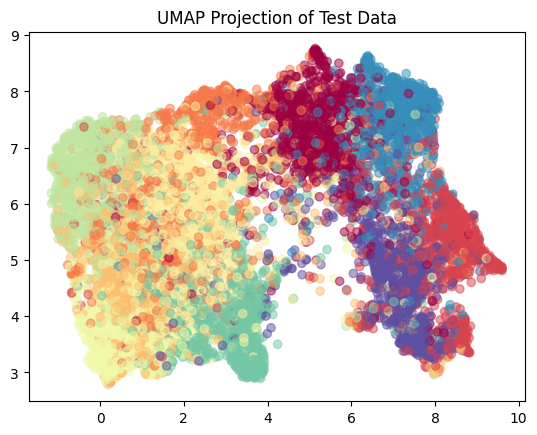

Model Performance on adversary test set
0.5411


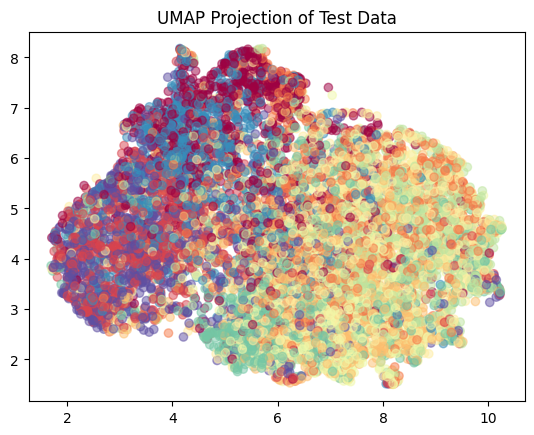

In [15]:
train_loader, val_loader, test_loader = load_data(batch_size, val_split, path_save_data, shuffle_=False)

### Evaluate the model on test data ###
print('Model Performance on train set')
print(knn_accuracy(model, train_loader))
plot_umap(model, train_loader)

### Evaluate the model on val data ###
print('Model Performance on val set')
print(knn_accuracy(model, val_loader))
plot_umap(model, val_loader)

### Evaluate the model on test data ###
print('Model Performance on test set')
print(knn_accuracy(model, test_loader))
plot_umap(model, test_loader)



### Generate adversary test loader ###
# List to store noisy images and labels
adv_images = []
adv_labels = []
# Generate noisy images
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    # Generate adversarial samples
    adversary_images = generate_adversary_samples(model, images, labels, loss_fn, epsilon=0.1, manual=False)
    adv_images.append(adversary_images)
    adv_labels.append(labels)
# Concatenate all tensors along the batch dimension
adv_images = torch.cat(adv_images, dim=0).to('cpu')
adv_labels = torch.cat(adv_labels, dim=0).to('cpu')
# Create a new DataLoader with noisy images
test_loader_adv = DataLoader(TensorDataset(adv_images, adv_labels), batch_size=test_loader.batch_size, shuffle=False)


### Evaluate the model on test data ###
print('Model Performance on adversary test set')
print(knn_accuracy(model, test_loader_adv))
plot_umap(model, test_loader_adv)



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch

# Function to plot label distribution
def plot_label_distribution(labels_train, labels_val, labels_test):
    plt.figure(figsize=(12, 4))
    
    sns.histplot(labels_train, bins=10, color='blue', label='Train', kde=True)
    sns.histplot(labels_val, bins=10, color='green', label='Validation', kde=True)
    sns.histplot(labels_test, bins=10, color='red', label='Test', kde=True)
    
    plt.title('Label Distribution Across Train, Validation, and Test Sets')
    plt.xlabel('Class')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

# Function to display sample images
def plot_sample_images(loader, title, n_samples=10):
    data_iter = iter(loader)
    images, labels = next(data_iter)
    
    plt.figure(figsize=(15, 2))
    for i in range(n_samples):
        img = images[i].permute(1, 2, 0).cpu().numpy()
        img = img * 0.5 + 0.5  # Unnormalize (if normalized)
        
        plt.subplot(1, n_samples, i + 1)
        plt.imshow(img)
        plt.title(f'Label: {labels[i].item()}')
        plt.axis('off')
        
    plt.suptitle(title)
    plt.show()

# Function to identify label inconsistencies
def check_label_consistency(loader):
    all_labels = []
    for _, labels in loader:
        all_labels.extend(labels.cpu().numpy())
    
    unique_labels = set(all_labels)
    print(f"Unique labels: {sorted(unique_labels)}")
    print(f"Label counts: {np.bincount(all_labels)}")

# ✅ Step 1: Plot Label Distribution
plot_label_distribution(labels_train, labels_val, labels_test)

# ✅ Step 2: Show Sample Images from Each Set
plot_sample_images(train_loader, 'Train Set Samples')
plot_sample_images(val_loader, 'Validation Set Samples')
plot_sample_images(test_loader, 'Test Set Samples')

# ✅ Step 3: Check for Label Consistency
print("Checking Train Set...")
check_label_consistency(train_loader)
print("\nChecking Validation Set...")
check_label_consistency(val_loader)
print("\nChecking Test Set...")
check_label_consistency(test_loader)


In [ ]:
import torch
import torchvision.models as models

# Move to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Dummy input (batch size=1, 3 channels, 224x224 image)
dummy_input = torch.randn(1, 3, 224, 224).to(device)

# Dictionary to store layer outputs
layer_outputs = {}

# Function to register hook
def hook_fn(name):
    def hook(module, input, output):
        layer_outputs[name] = output.shape  # Store output shape
    return hook

# Register hooks for all layers
for name, layer in model.named_modules():
    layer.register_forward_hook(hook_fn(name))

# Forward pass
_ = model(dummy_input)

# Print output shapes
for layer_name, output_shape in layer_outputs.items():
    print(f"{layer_name}: {output_shape}")


In [ ]:

import random
import matplotlib.pyplot as plt


def data_visualization(batch_data, figsize = (3,3)):
    batch_image, lbl = batch_data
    batch_size = batch_image.shape[0]

    # random_batch_index = random.randint(0, batch_size-1)
    random_batch_index = 0
    random_image, random_lbl = batch_image[random_batch_index], lbl[random_batch_index]
    
    image_transposed = random_image.detach().numpy().transpose((1, 2, 0))
    fig, ax = plt.subplots(1, figsize=figsize)
    ax.imshow(image_transposed)
    ax.set_title(f"lbl:{random_lbl}")
    ax.set_axis_off()


# Plot sample image for each dataset
print("Plot sample image from train dataset")
sample = next(iter(train_loader))
data_visualization(batch_data=sample, figsize = (3,3))
print("Plot sample image from test dataset")
sample = next(iter(test_loader))
data_visualization(batch_data=sample, figsize = (3,3))
print("Plot sample image from val dataset")
sample = next(iter(val_loader))
data_visualization(batch_data=sample, figsize = (3,3))


In [ ]:
# Training
training(model, device, train_loader, val_loader, 
         loss_fn, optimizer, scheduler, epochs, 
         generate_adversary_samples if adv_tr else None, 
         model_path, model_name=model_name, plot_loss=True)

In [ ]:


### Generate adversary test loader ###
# List to store noisy images and labels
adv_images = []
adv_labels = []
# Generate noisy images
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    # Generate adversarial samples
    adversary_images = generate_adversary_samples(model, images, labels, loss_fn, epsilon=0.1, manual=False)
    adv_images.append(adversary_images)
    adv_labels.append(labels)
# Concatenate all tensors along the batch dimension
adv_images = torch.cat(adv_images, dim=0).to('cpu')
adv_labels = torch.cat(adv_labels, dim=0).to('cpu')
# Create a new DataLoader with noisy images
test_loader_adv = DataLoader(TensorDataset(adv_images, adv_labels), batch_size=test_loader.batch_size, shuffle=False)


### Evaluate the model on test data ###
print('Model Performance on test set')
print(knn_accuracy(model, test_loader))
plot_umap(model, test_loader)
print('Model Performance on adversary test set')
print(knn_accuracy(model, test_loader_adv))
plot_umap(model, test_loader_adv)



In [ ]:
import umap
import numpy as np
import matplotlib.pyplot as plt


# فرض کنیم اینها ویژگی‌های ترین، ولیدیشن و تست هستن:
features_train = extract_features(model, train_loader)  # ویژگی‌های train
features_val   = extract_features(model, val_loader)      # ویژگی‌های validation
features_test  = extract_features(model, test_loader)    # ویژگی‌های test

# برچسب‌های داده‌ها
    # labels = np.array([label for _, label in test_loader.dataset])
    # labels = torch.cat([labels for _, labels in test_loader], dim=0).cpu().numpy()
    # labels = torch.tensor(test_loader.dataset.targets).cpu().numpy()
labels_train = torch.cat([labels for _, labels in train_loader], dim=0).cpu().numpy()
labels_val   = torch.cat([labels for _, labels in val_loader], dim=0).cpu().numpy()
labels_test  = torch.cat([labels for _, labels in test_loader], dim=0).cpu().numpy()

# ✅ مرحله 1: ترکیب کردن تمام داده‌ها در یک ماتریس
features_all = np.concatenate([features_train, features_val, features_test], axis=0)
labels_all   = np.concatenate([labels_train, labels_val, labels_test], axis=0)


from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
features_all = scaler.fit_transform(features_all)


# ✅ مرحله 2: اجرای UMAP روی کل داده‌ها
umap_model = umap.UMAP(n_neighbors=50, min_dist=0.1, n_components=2, random_state=42)
embedding  = umap_model.fit_transform(features_all)


# ✅ مرحله 3: جدا کردن داده‌های train, val, test بعد از کاهش ابعاد
n_train = len(features_train)
n_val   = len(features_val)

embedding_train = embedding[:n_train]
embedding_val   = embedding[n_train:n_train + n_val]
embedding_test  = embedding[n_train + n_val:]

# ✅ مرحله 4: رسم داده‌های train, val, test با رنگ‌های متفاوت
plt.scatter(embedding_train[:, 0], embedding_train[:, 1], c=labels_train, alpha=0.5, label="Train")
plt.title("UMAP Projection of Train")
plt.show()
plt.scatter(embedding_val[:, 0], embedding_val[:, 1], c=labels_val, alpha=0.5, label="Validation")
plt.title("UMAP Projection of Validation")
plt.show()
plt.scatter(embedding_test[:, 0], embedding_test[:, 1], c=labels_test, alpha=0.5, label="Test")
plt.title("UMAP Projection of Test")
plt.show()


In [ ]:
train_mean = features_train.mean(axis=0)
val_mean = features_val.mean(axis=0)
test_mean = features_test.mean(axis=0)

plt.figure(figsize=(10, 5))
plt.plot(train_mean, label="Train", alpha=0.7)
plt.plot(val_mean, label="Validation", alpha=0.7)
plt.plot(test_mean, label="Test", alpha=0.7)
plt.legend()
plt.title("Mean of Extracted Features")
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch

# Function to plot label distribution
def plot_label_distribution(labels_train, labels_val, labels_test):
    plt.figure(figsize=(12, 4))
    
    sns.histplot(labels_train, bins=10, color='blue', label='Train', kde=True)
    sns.histplot(labels_val, bins=10, color='green', label='Validation', kde=True)
    sns.histplot(labels_test, bins=10, color='red', label='Test', kde=True)
    
    plt.title('Label Distribution Across Train, Validation, and Test Sets')
    plt.xlabel('Class')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

# Function to display sample images
def plot_sample_images(loader, title, n_samples=10):
    data_iter = iter(loader)
    images, labels = next(data_iter)
    
    plt.figure(figsize=(15, 2))
    for i in range(n_samples):
        img = images[i].permute(1, 2, 0).cpu().numpy()
        img = img * 0.5 + 0.5  # Unnormalize (if normalized)
        
        plt.subplot(1, n_samples, i + 1)
        plt.imshow(img)
        plt.title(f'Label: {labels[i].item()}')
        plt.axis('off')
        
    plt.suptitle(title)
    plt.show()

# Function to identify label inconsistencies
def check_label_consistency(loader):
    all_labels = []
    for _, labels in loader:
        all_labels.extend(labels.cpu().numpy())
    
    unique_labels = set(all_labels)
    print(f"Unique labels: {sorted(unique_labels)}")
    print(f"Label counts: {np.bincount(all_labels)}")

# ✅ Step 1: Plot Label Distribution
plot_label_distribution(labels_train, labels_val, labels_test)

# ✅ Step 2: Show Sample Images from Each Set
plot_sample_images(train_loader, 'Train Set Samples')
plot_sample_images(val_loader, 'Validation Set Samples')
plot_sample_images(test_loader, 'Test Set Samples')

# ✅ Step 3: Check for Label Consistency
print("Checking Train Set...")
check_label_consistency(train_loader)
print("\nChecking Validation Set...")
check_label_consistency(val_loader)
print("\nChecking Test Set...")
check_label_consistency(test_loader)


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# اجرای PCA روی داده‌های Train و Test
pca = PCA(n_components=2)
train_pca = pca.fit_transform(features_train)
val_pca = pca.fit_transform(features_val)
test_pca = pca.transform(features_test)  # دقت کن که Test فقط transform میشه!

# تعریف رنگ‌های مختلف برای 10 کلاس
palette = sns.color_palette("tab10", 10)

# رسم نمودار Train
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
for i in range(10):
    idx = labels_train == i
    plt.scatter(train_pca[idx, 0], train_pca[idx, 1], label=f'Class {i}', color=palette[i], alpha=0.6, s=10)
plt.title("PCA Projection - Train Data")
plt.legend()
plt.grid(False)

# رسم نمودار val
plt.subplot(1, 3, 2)
for i in range(10):
    idx = labels_val == i
    plt.scatter(val_pca[idx, 0], val_pca[idx, 1], label=f'Class {i}', color=palette[i], alpha=0.6, s=10)
plt.title("PCA Projection - val Data")
plt.legend()
plt.grid(False)


# رسم نمودار Test
plt.subplot(1, 3, 3)
for i in range(10):
    idx = labels_test == i
    plt.scatter(test_pca[idx, 0], test_pca[idx, 1], label=f'Class {i}', color=palette[i], alpha=0.6, s=10)
plt.title("PCA Projection - Test Data")
plt.legend()
plt.grid(False)

plt.show()


In [ ]:

# Visualize feature distribution using UMAP
def plot_umap(model, test_loader):
    features = extract_features(model, test_loader)
    # labels = np.array([label for _, label in test_loader.dataset])
    labels = torch.cat([labels for _, labels in test_loader], dim=0).cpu().numpy()
    # labels = torch.tensor(test_loader.dataset.targets).cpu().numpy()
    
    umap_proj = umap.UMAP(n_components=2).fit_transform(features)
    plt.scatter(umap_proj[:, 0], umap_proj[:, 1], c=labels, cmap='Spectral', alpha=0.5)
    plt.title("UMAP Projection of Test Data")
    plt.show()



train_loader, val_loader, test_loader = load_data(batch_size, val_split, path_save_data)

### Evaluate the model on test data ###
print('Model Performance on train set')
plot_umap(model, train_loader)

### Evaluate the model on val data ###
print('Model Performance on val set')
plot_umap(model, val_loader)

### Evaluate the model on test data ###
print('Model Performance on test set')
plot_umap(model, test_loader)


In [ ]:
# Extract features and labels from train and test loaders
train_features = extract_features(model, train_loader)
train_labels = torch.cat([labels for _, labels in train_loader], dim=0).cpu().numpy()

val_features = extract_features(model, val_loader)
val_labels = torch.cat([labels for _, labels in val_loader], dim=0).cpu().numpy()

# Train on train set, evaluate on val
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(train_features, train_labels)
val_acc = knn.score(val_features, val_labels)
print("KNN accuracy on validation set:", val_acc)


In [ ]:
import torch
import torchvision
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torch.utils.data as data
from cleverhans.torch.attacks.fast_gradient_method import fast_gradient_method
import numpy as np
import math


def load_data(batch_size=64, val_split=0.2, data_path='.'):
    """Loads the CIFAR-10 dataset and prepares DataLoaders for training, validation, and testing.

    This function applies transformations, splits the training dataset into training and validation sets,
    and returns DataLoaders for efficient batch processing.

    Args:
        batch_size (int, optional): Number of samples per batch. Defaults to 64.
        val_split (float, optional): Proportion of training data to use for validation (0 to 1). Defaults to 0.2.
        data_path (str, optional): Directory path to download or load the CIFAR-10 dataset. Defaults to '.'.

    Returns:
        tuple: A tuple containing:
            - train_loader (DataLoader): DataLoader for the training set.
            - val_loader (DataLoader): DataLoader for the validation set.
            - test_loader (DataLoader): DataLoader for the test set.
    """

    # Define transforms
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2470, 0.2435, 0.2616]),
    ])

    # Load CIFAR-10 dataset
    train_ds = torchvision.datasets.CIFAR10(root=data_path, train=True, transform=transform, download=True)
    test_ds  = torchvision.datasets.CIFAR10(root=data_path, train=False, transform=transform,download=True)

    # Split train and validation datasets
    indices = np.arange(len(train_ds))
    np.random.shuffle(indices)
    val_size = math.floor(len(train_ds) * val_split)
    train_idx, val_idx = indices[val_size:], indices[:val_size]
    
    # train_sampler = data.SubsetRandomSampler(train_idx)
    # val_sampler   = data.SubsetRandomSampler(val_idx)

    # # Create data loader
    # train_loader = DataLoader(train_ds, batch_size, sampler=train_sampler)
    # val_loader   = DataLoader(train_ds, batch_size, sampler=val_sampler)
    # test_loader  = DataLoader(test_ds, batch_size, shuffle=True)


    val_ds = torch.utils.data.Subset(train_ds, val_idx)
    train_ds = torch.utils.data.Subset(train_ds, train_idx)
    
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_ds, batch_size, shuffle=True)

    return train_loader, val_loader, test_loader


def generate_adversary_samples(model, images, labels, loss_fn, epsilon=0.1, manual=False, num_pixels=10):
    """
    1. Generates adversarial examples using the Fast Gradient Sign Method (FGSM).
        FGSM attack perturbs the input images to maximize the model's loss, thereby generating adversarial examples.
        The attack can be performed using a manual implementation or CleverHans' `fast_gradient_method`.
    2. Add random noise by change some pixels of the image to a fixed value.


    Args:
        model (torch.nn.Module): The target model to attack.
        images (torch.Tensor): Input images.
        labels (torch.Tensor): True labels corresponding to the input images.
        loss_fn (callable): Loss function used for computing gradients.
        epsilon (float, optional): Magnitude of the perturbation. Defaults to 0.1.
        manual (bool, optional): Whether to use a manual FGSM implementation. Defaults to False.
        num_pixels (int, optional): The number of pixels that change. Defaults to 10.

    Returns:
        torch.Tensor: Adversarial examples generated by FGSM attack and random noise.
    """

    ### FGSM attack ###
    # clone().detach(): create a new copy without dependency on the computation graph.
    images = images.clone().detach().requires_grad_(True)
    batch_size, _, height, width = images.shape
    
    if manual:
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        model.zero_grad()
        loss.backward()
        perturbation = torch.sign(images.grad) * epsilon
        adversary_images = images + perturbation
        # adversary_images = torch.clamp(adversary_images, -1, 1)
        adversary_images = torch.clamp(adversary_images, 0, 1)
    else:
        adversary_images = fast_gradient_method(model, images, epsilon, np.inf)


    ### Add random noise ###
    # adversary_images = adversary_images.clone().detach()
    for i in range(batch_size):
        for _ in range(num_pixels):
            h, w = np.random.randint(0, height), np.random.randint(0, width)
            adversary_images[i, :, h, w] = 1.0  # Whitening the pixel.

    return adversary_images # .detach()



In [ ]:
# Define transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2470, 0.2435, 0.2616]),
])

train_ds = torchvision.datasets.CIFAR10(root='.', train=True, transform=transform, download=True)
test_ds  = torchvision.datasets.CIFAR10(root='.', train=False, transform=transform,download=True)

# Split train and validation datasets
indices = np.arange(len(train_ds))
np.random.shuffle(indices)
val_size = math.floor(len(train_ds) * val_split)
train_idx, val_idx = indices[val_size:], indices[:val_size]

val_ds = torch.utils.data.Subset(train_ds, val_idx)
train_ds = torch.utils.data.Subset(train_ds, train_idx)


from collections import Counter
train_classes = [label for _, label in train_ds]
val_classes = [label for _, label in val_ds]
test_classes = [label for _, label in test_ds]

print("Train distribution:", Counter(train_classes))
print("Validation distribution:", Counter(val_classes))
print("Test distribution:", Counter(test_classes))


In [ ]:
print("Plot sample image from adv test dataset")
sample = next(iter(test_loader_adv))
data_visualization(batch_data=sample, figsize = (3,3))


In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import torch


def model_performance(model, test_loader):
    # Assuming `model` is your trained model
    model.eval()
    
    y_true_list = []
    y_pred_list = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)  # Get predictions
            _, predicted = torch.max(outputs, 1)  # Convert to class labels
    
            y_true_list.append(labels.cpu().numpy())  
            y_pred_list.append(predicted.cpu().numpy())  
    
    # Convert lists to NumPy arrays
    y_true = np.concatenate(y_true_list)
    y_pred = np.concatenate(y_pred_list)
    
    # Compute confusion matrix
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    
    # Assuming y_true and y_pred are your true and predicted labels
    print("\nClassification report:\n", classification_report(y_true, y_pred, digits=4))


In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import torch

# Assuming `model` is your trained model
model.eval()

y_true_list = []
y_pred_list = []

with torch.no_grad():
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        outputs = model(images)  # Get predictions
        _, predicted = torch.max(outputs, 1)  # Convert to class labels

        y_true_list.append(labels.cpu().numpy())  
        y_pred_list.append(predicted.cpu().numpy())  

# Convert lists to NumPy arrays
y_true = np.concatenate(y_true_list)
y_pred = np.concatenate(y_pred_list)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

# Assuming y_true and y_pred are your true and predicted labels
report = classification_report(y_true, y_pred, digits=4)
print(report)


In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import torch

# Assuming `model` is your trained model
model.eval()

y_true_list = []
y_pred_list = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        
        outputs = model(images)  # Get predictions
        _, predicted = torch.max(outputs, 1)  # Convert to class labels

        y_true_list.append(labels.cpu().numpy())  
        y_pred_list.append(predicted.cpu().numpy())  

# Convert lists to NumPy arrays
y_true = np.concatenate(y_true_list)
y_pred = np.concatenate(y_pred_list)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

# Assuming y_true and y_pred are your true and predicted labels
report = classification_report(y_true, y_pred, digits=4)
print(report)


